# Documenting Data Analysis with Jupyter Lab

#### Joe Wu, Phd
#### NCI/CCR Bioinformatics Training and Education Program
#### ncibtep@nih.gov
#### September 24, 2024

Table of contents

* [Start a Jupyter Lab session](#Start-Jupyter-Lab)
* [Jupyter Lab interface](#Jupyter-Lab-interface)
* [Jupyter Lab file explorer](#Jupyter-Lab-file-explorer)
* [Keeping code, output and analysis steps all in one place](#Keeping-code-output-and-analysis-steps-all-in-one-place)
* [Changing between markdown and code](#Changing-between-markdown-and-code)
* [Ways to access and use Jupyter Lab](#Ways-to-access-and-use-Jupyter-Lab)
* [Writing formatted text](#Writing-formatted-text)
* [Code and visualization](#Code-and-visualization)
* [Exporting Jupyter Notebook using GUI](#Exporting-Jupyter-Notebook-using-GUI)
* [Exporting Jupyter Notebook using command line](#Exporting-Jupyter-Notebook-using-command-line)
* [Sharing Jupyter Notebook](#Sharing-Jupyter-Notebook)

## Start Jupyter Lab

To start Jupyter Lab, type the following into the command prompt. The `--no-browser` option prevents a web browser from opening.

```
jupyter lab --no-browser
```

Copy and paste any of the following URLs into a web browser to start using Jupyter. These URLs will be different for every Jupyter Lab session.

```
To access the server, open this file in a browser:
        file:///Users/wuz8/Library/Jupyter/runtime/jpserver-30985-open.html
    Or copy and paste one of these URLs:
        http://localhost:8890/lab?token=1952fcce201164f8368f2666f2f2625c0bbeeea1ddc20b2c
        http://127.0.0.1:8890/lab?token=1952fcce201164f8368f2666f2f2625c0bbeeea1ddc20b2c
```

:::{tip}
Start a Jupyter Lab session in the project folder. This folder will contain input and analysis output.
:::

#### Jupyter Lab interface

<img src="../images/jupyter_1.png" />

#### Jupyter Lab is compatible with many languages

* Bash, Python, and R
* See [https://github.com/jupyter/jupyter/wiki/Jupyter-kernels](http://localhost:5808/) for a list of Jupyter compatible languages

#### Jupyter Lab file explorer

<img src="../images/jupyter_2.png" />

#### Start a Python Jupyter Notebook

Click on the "Python 3 (ipykernel)" tab to start a Python Jupyter Noteook.
The Jupyter Notebook is a part of Jupyter Lab.

The note book is where users

* Write code
* View output
* Document analysis steps using formatted text written in markdown

:::{note}
"Markdown is a lightweight markup language for creating formatted text using a plain-text editor." -- [https://en.wikipedia.org/wiki/Markdown](https://en.wikipedia.org/wiki/Markdown)
:::

#### Keeping code, output and analysis steps all in one place

<img src="../images/jupyter_3.png" />

:::{note}
A new Jupyter Notebook is given the name "Untitled". Change this to something meaningful either using the save icon on the notebook menu bar or right-clicking on the "Untitled" notebook in the file explorer and choose "Rename".

Jupyter Notebooks have extension ipynb, which stands for interactive Python notebook.
:::

#### Changing between markdown and code

<img src="../images/jupyter_4.png" />

## Ways to access and use Jupyter Lab

* Install on local machine (see [https://github.com/jupyter/jupyter/wiki/Jupyter-kernels](https://github.com/jupyter/jupyter/wiki/Jupyter-kernels))
* Available on Biowulf (see [https://hpc.nih.gov/apps/jupyter.html](https://hpc.nih.gov/apps/jupyter.html))

## Writing formatted text

See [https://www.markdownguide.org/basic-syntax/](https://www.markdownguide.org/basic-syntax/) for a markdown guide.

#### Custom heading sizes

Use `#` to specify heading levels

```
# Heading level 1 (largest)
## Heading level 2 (second largest)
### Heading level 3 (third largest)
...
```

#### Lists

Un-ordered lists: use `*` or `-`

```
- DNA
- RNA
- protein
- metabolite
```

Ordered list: use numbers

```
1. Obtain sequencing data
2. Perform pre-alignment QC
3. Adapter and/or quality trim
3. Align sequencing data to reference genome
4. Obtain gene expression count matrix
5. Run differential expression analysis
6. Pathway analysis
```

#### Insert images

`<img src="image_path" />`

#### Insert links

`[Description of website](insert url)`

## Code and visualization

#### Import data using Pandas

[Pandas](https://pandas.pydata.org) is a Python package used for working with tabular data. The dataset used here is the differential gene expression analysis results from the [HBR and UHR study](https://rnabio.org/module-01-inputs/0001/05/01/RNAseq_Data/). To work with this, users will need to import it using the `read_csv` function of Pandas as the data is a csv file (hbr_uhr_deg_chr22_with_significance.csv located in the folder jupyter_summer_series_2023_data). The path to this file is used as the **argument** for the `read_csv` function.

In [1]:
# Load the Pandas package
import pandas

In [2]:
# Import the data

hbr_uhr_deg_chr22=pandas.read_csv("./jupyter_data/hbr_uhr_deg_chr22_with_significance.csv")

# View the first several lines of hbr_uhr_deg_chr22
hbr_uhr_deg_chr22.head()

,name,log2FoldChange,PAdj,-log10PAdj,significance
0,SYNGR1,-4.6,5.200000e-217,216.283997,down
1,SEPT3,-4.6,4.500000e-204,203.346787,down
2,YWHAH,-2.5,4.700000e-191,190.327902,down
3,RPL3,1.7,5.400000e-134,133.267606,ns
4,PI4KA,-2.0,2.900000e-118,117.537602,down


#### Construct volcano plot using Seaborn

[Seaborn](https://seaborn.pydata.org) is a popular visualization package for Python. Users can use its `scatterplot` function to generate scatter plots (in this case a volcano plot), which will take on arguments:

* Data: hbr_uhr_deg_chr22 (differential gene expression analysis results)
* `x`: x-axis values (ie. gene expression log2FoldChange)
* `y`: y-axis values (ie. -log10 of adjusted p-value)
* `hue`: color dots by whether gene expression change is up, down, or has no change (see signifcance column of the data)

<Axes: xlabel='log2FoldChange', ylabel='-log10PAdj'>

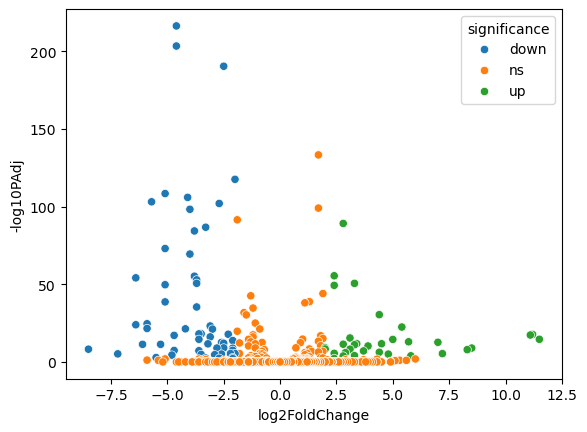

In [3]:
## Load the seaborn plotting package
import seaborn

seaborn.scatterplot(hbr_uhr_deg_chr22,x="log2FoldChange", y="-log10PAdj", hue="significance")

The volcano plot is a special scatter plot that depicts gene expression change versus the statistical significance of the change.

#### Construct heatmap using Seaborn

This exercise will use Seaborn's `clustermap` function to construct a gene expression heatmap of top differentially expressed genes in the HBR and UHR study. Heatmaps are another common visualization in RNA sequencing and allow users to identify clusters of samples with similar gene expression patterns.

First, import the dataset using `pandas.read_csv`. The `clustermap` function of seaborn takes the following arguments and options.

* Data: hbr_uhr_top_deg_normalized_counts
* `z_score`: z-score scale the gene expression counts
* `cmap`: specify a coloring scheme (ie. viridis)
* `figsize`: specify figure size
* `cbar_kws`: specify title for the heatmap color bar using a key-value pair
* `cbar_pos`: specify coordinate to place the heatmap color bar

In [4]:
# Import the data

hbr_uhr_top_deg_normalized_counts=pandas.read_csv("./jupyter_data/hbr_uhr_top_deg_normalized_counts.csv", index_col=0)

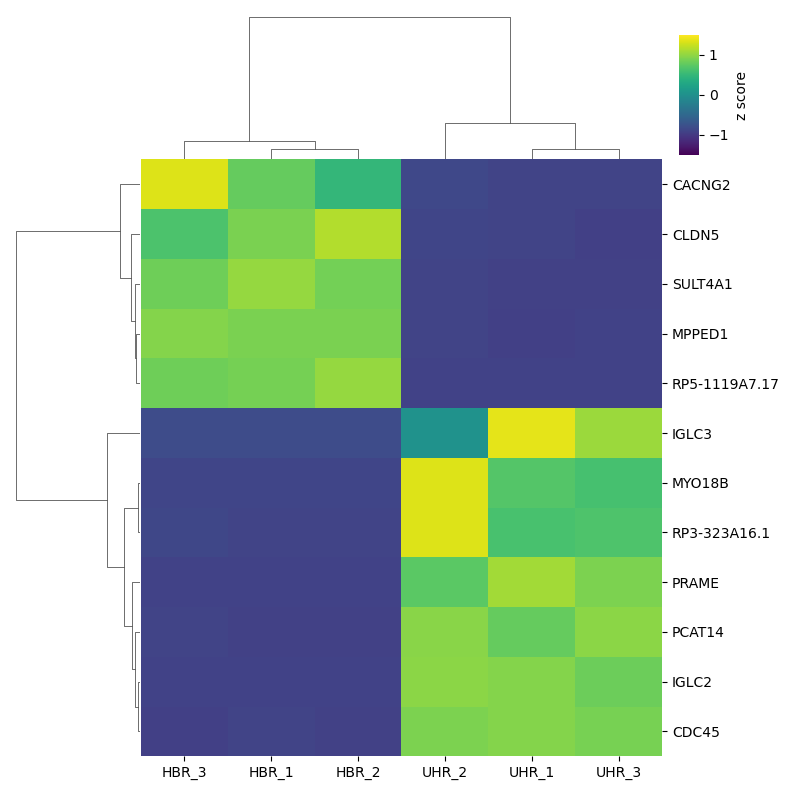

In [5]:
seaborn.clustermap(hbr_uhr_top_deg_normalized_counts,z_score=0,cmap="viridis",
                   figsize=(8,8),vmin=-1.5, vmax=1.5,cbar_kws=({"label": "z score"}),
                   cbar_pos=(0.855,0.8,0.025,0.15))

#### R code in a Python Jupyter Notebook

Using the `rpy2.ipython` package, users can run R code inside a Python Jupyter Notebook.

In [6]:
# Load rpy2.ipython
%load_ext rpy2.ipython

#### Using R to generate a principal components plot

Here, R will be used to generate principal components plot for the HBR and UHR study. Principal components plots are a popular way to visualize how samples in RNA sequencing cluster based on gene expression.

In [7]:
%%R
# Load packages using the library command
library(ggfortify)

Loading required package: ggplot2


In [8]:
%%R
# Import gene expression data using read.csv and store is as variable counts
counts <- read.csv("./jupyter_data/hbr_uhr_normalized_counts_pca.csv")

In [9]:
%%R
# Look at the first few lines of counts
head(counts)

    Samples Treatment SULT4A1 MPPED1 PRAME IGLC2 IGLC3 CDC45 CLDN5 PCAT14
1 HBR_1.bam       HBR   375.0  157.8   0.0   0.0   0.0   2.6  77.6    0.0
2 HBR_2.bam       HBR   343.6  158.4   0.0   0.0   0.0   1.0  88.5    0.0
3 HBR_3.bam       HBR   339.4  162.6   0.0   0.0   0.0   0.0  67.2    1.2
4 UHR_1.bam       UHR     3.5    0.7 568.9 488.6 809.7 155.0   1.4  139.8
5 UHR_2.bam       UHR     6.9    3.0 467.3 498.0 313.8 152.5   2.0  154.4
6 UHR_3.bam       UHR     2.6    2.6 519.2 457.5 688.0 149.9   0.0  155.1
  RP5.1119A7.17 MYO18B RP3.323A16.1 CACNG2
1          53.0    0.0          0.0   42.7
2          57.6    0.0          0.0   35.0
3          51.9    0.0          1.2   56.6
4           0.0   59.5         51.9    0.0
5           0.0   84.2         76.2    1.0
6           0.0   56.5         53.1    0.0


The `autoplot` command takes the following arguments

* Principal components analysis results, which are stored in hbr_uhr_pca
* `data`: Expression counts table, which is stored as counts
* `colour`: column in the expression counts table to color the samples by (here color by Treatment)
* `size`: specify size of the dots

The layer theme was added to the principal components plot to customize the font sizes.

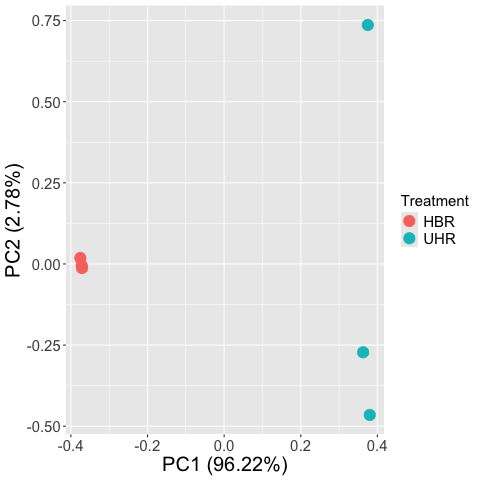

In [10]:
%%R

# Run principal components analysis on counts using the prcomp function
hbr_uhr_pca <- prcomp(counts[3:14],scale.=TRUE,center=TRUE)

# Construct principal components plot.

autoplot(hbr_uhr_pca,data=counts,colour="Treatment",size=5)+
        theme(axis.title=element_text(size=20),
              axis.text=element_text(size=15),
              legend.title=element_text(size=15),
              legend.text=element_text(size=15))

#### Running Unix commands

Users can run Unix commands within a Python Jupyter Notebook. To do this start a code block with "!" followed by the unix command. For instance, using the `pwd` command in the code block below to list the present working directory.

In [11]:
!pwd

/Users/wuz8/Library/CloudStorage/OneDrive-NationalInstitutesofHealth/tutorials/document_analysis_with_jupyter/docs/data


## Exporting Jupyter Notebook using GUI

<img src="../images/jupyter_5.png" width="50%"/>

## Exporting Jupyter Notebook using command line

Use the `jupyter nbconvert` command at the command prompt to convert Jupyter Notebook to various available format, including html, pdf, and slides. The format is specified after the `--to` option.

```
jupyter nbconvert --to format
```

## Sharing Jupyter Notebook

- [Github](https://github.com)
    - Static notebook (ie. users will not be able to run)
- [Binder](https://mybinder.org)
    - Provide data
    - Provide list of packages
    - Users can run the notebook
    - [Example](https://mybinder.org/v2/gh/ncbi/workshop-ncbi-data-with-python/main?filepath=notebooks%2Fworkshop.py)